In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd


C:\Users\Abhi\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Abhi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df=pd.read_csv("novagen_dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

In [4]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

In [6]:
x=df.drop('Target',axis=1)
y=df['Target']

In [7]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
    

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)  
X_test_scaled = scaler.transform(x_test) 

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8225130890052356


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.8952879581151832


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rf_acc=accuracy_score(y_test, y_pred_rf)
print("RF Accuracy:",rf_acc)

RF Accuracy: 0.9408376963350785


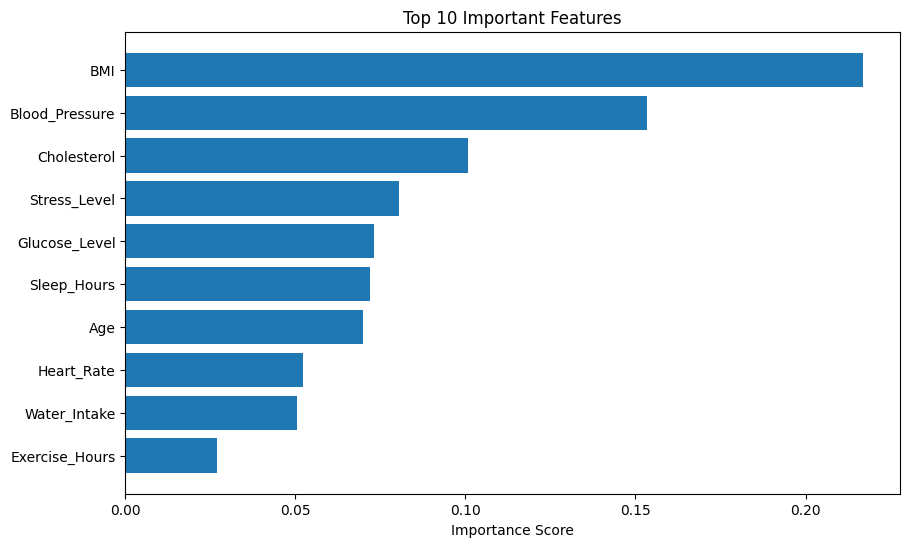

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)

gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_acc)
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9183246073298429
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       900
           1       0.92      0.92      0.92      1010

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



In [14]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression()),
        ("svc", SVC(probability=True)),
        ("dtc", DecisionTreeClassifier())
    ],
    voting='hard'
)

voting.fit(X_train_scaled, y_train)

y_pred_vote = voting.predict(X_test_scaled)

print("Voting Accuracy:",
      accuracy_score(y_test, y_pred_vote))

Voting Accuracy: 0.925130890052356


In [41]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
svc=SVC()
lr=LogisticRegression()
dtc=DecisionTreeClassifier()
staking=StackingClassifier(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)]
)
staking.fit(X_train_scaled,y_train)
y_pred=staking.predict(X_test_scaled)
print("Stacking Classifier:",
      accuracy_score(y_test, y_pred))

Stacking Classifier: 0.9424083769633508


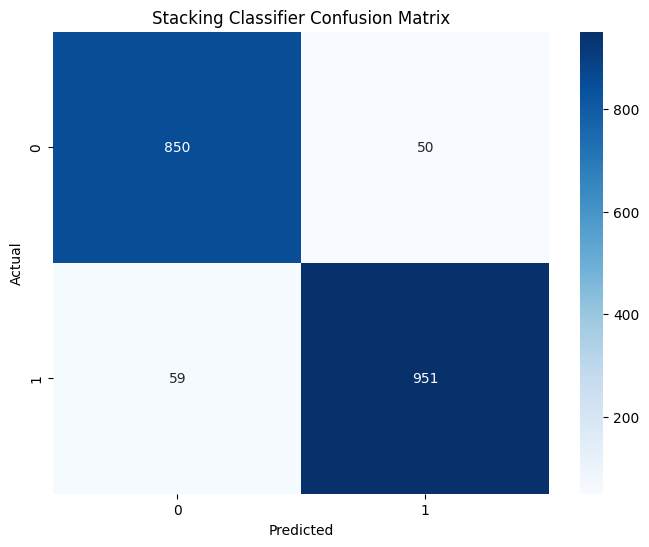

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Stacking Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Voting Classifier",
        "Stacking Classifier"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_vote),
        accuracy_score(y_test, y_pred)
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                 Model  Accuracy
5  Stacking Classifier  0.942408
2        Random Forest  0.940838
4    Voting Classifier  0.925131
3    Gradient Boosting  0.918325
1        Decision Tree  0.895288
0  Logistic Regression  0.822513


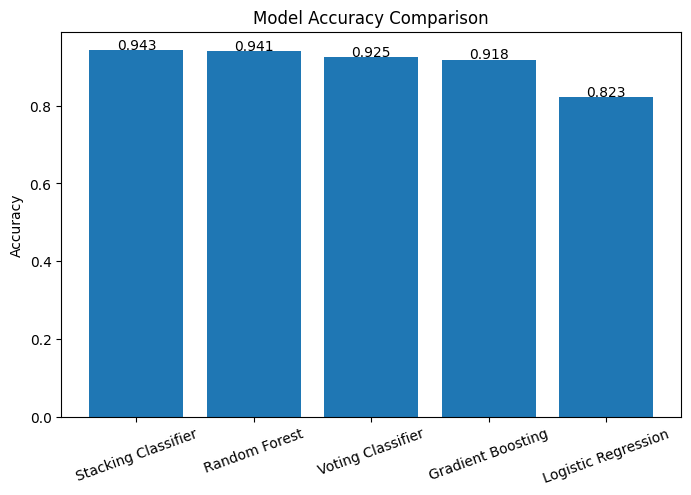

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v+0.002, f"{v:.3f}", ha='center')

plt.show()